In [7]:
import pandas as pd

df = pd.read_excel("merged_cleaned_retail_data.xlsx")

print(df.head())

print(df.shape)

   Invoice Stock Code                          Description  Quantity  \
0   489434      85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1   489434     79323P                   PINK CHERRY LIGHTS        12   
2   489434     79323W                  WHITE CHERRY LIGHTS        12   
3   489434      22041         RECORD FRAME 7" SINGLE SIZE         48   
4   489434      21232       STRAWBERRY CERAMIC TRINKET BOX        24   

         Invoice Date  Price  Customer ID         Country  Total_Amount  Year  \
0 2009-12-01 07:45:00   6.95        13085  United Kingdom          83.4  2009   
1 2009-12-01 07:45:00   6.75        13085  United Kingdom          81.0  2009   
2 2009-12-01 07:45:00   6.75        13085  United Kingdom          81.0  2009   
3 2009-12-01 07:45:00   2.10        13085  United Kingdom         100.8  2009   
4 2009-12-01 07:45:00   1.25        13085  United Kingdom          30.0  2009   

   Month  Day  Weekday Product_Category  Cost_Price  Profit Customer_Type  \
0  

In [9]:
print(df.isnull().sum())

Invoice             0
Stock Code          0
Description         0
Quantity            0
Invoice Date        0
Price               0
Customer ID         0
Country             0
Total_Amount        0
Year                0
Month               0
Day                 0
Weekday             0
Product_Category    0
Cost_Price          0
Profit              0
Customer_Type       0
Churn               0
Current_Stock       0
dtype: int64


In [11]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 793609 entries, 0 to 793608
Data columns (total 19 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Invoice           793609 non-null  int64         
 1   Stock Code        793609 non-null  object        
 2   Description       793609 non-null  object        
 3   Quantity          793609 non-null  int64         
 4   Invoice Date      793609 non-null  datetime64[ns]
 5   Price             793609 non-null  float64       
 6   Customer ID       793609 non-null  int64         
 7   Country           793609 non-null  object        
 8   Total_Amount      793609 non-null  float64       
 9   Year              793609 non-null  int64         
 10  Month             793609 non-null  int64         
 11  Day               793609 non-null  int64         
 12  Weekday           793609 non-null  object        
 13  Product_Category  793609 non-null  object        
 14  Cost

In [7]:
print(df.describe())

             Invoice       Quantity                   Invoice Date  \
count  793609.000000  793609.000000                         793609   
mean   537423.567202      13.446900  2011-01-02 13:32:54.594164224   
min    489434.000000       1.000000            2009-12-01 07:45:00   
25%    514967.000000       2.000000            2010-07-07 12:21:00   
50%    537042.000000       6.000000            2010-12-05 10:45:00   
75%    561616.000000      12.000000            2011-07-28 13:02:00   
max    581587.000000   80995.000000            2011-12-09 12:50:00   
std     26660.238547     144.693151                            NaN   

               Price    Customer ID   Total_Amount           Year  \
count  793609.000000  793609.000000  793609.000000  793609.000000   
mean        3.216821   15325.072507      22.284854    2010.424329   
min         0.001000   12346.000000       0.001000    2009.000000   
25%         1.250000   13975.000000       4.950000    2010.000000   
50%         1.950000   1

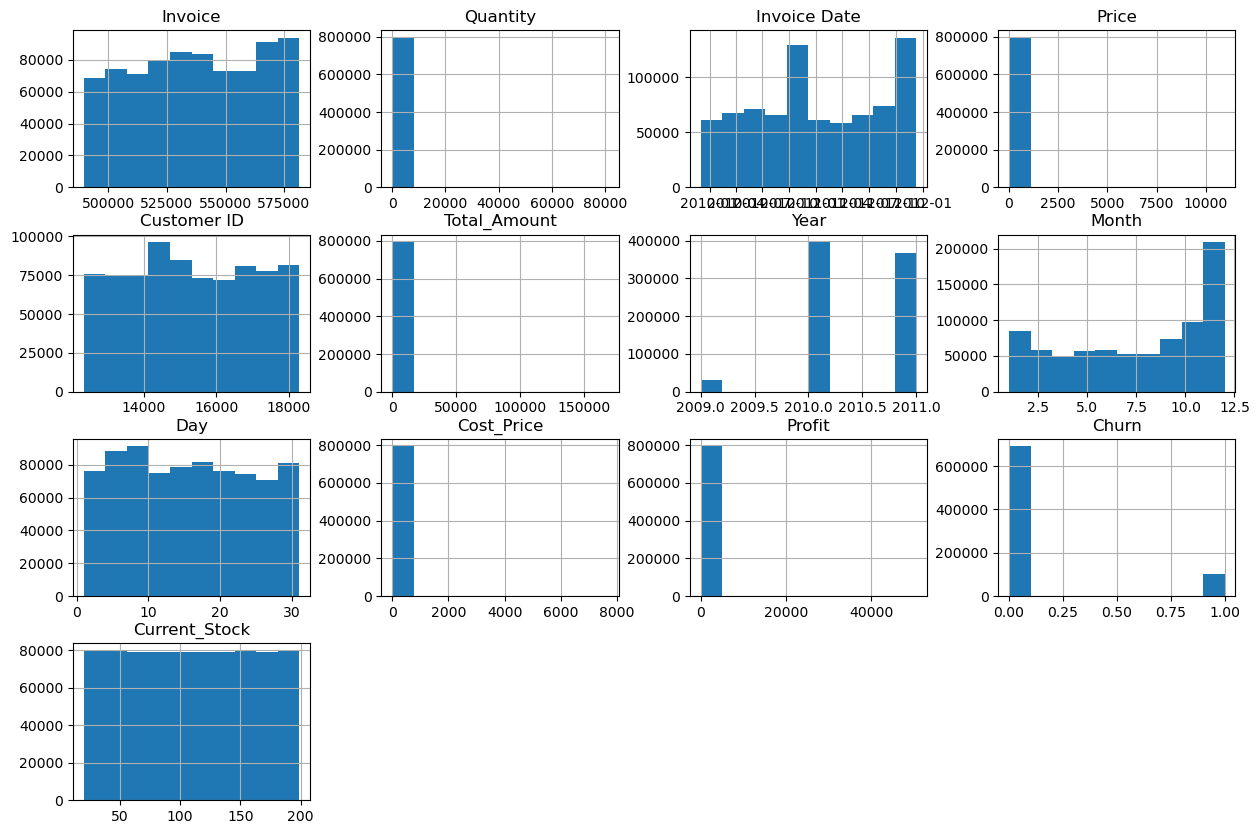

In [13]:
import matplotlib.pyplot as plt

df.hist(figsize=(15,10))

plt.show()

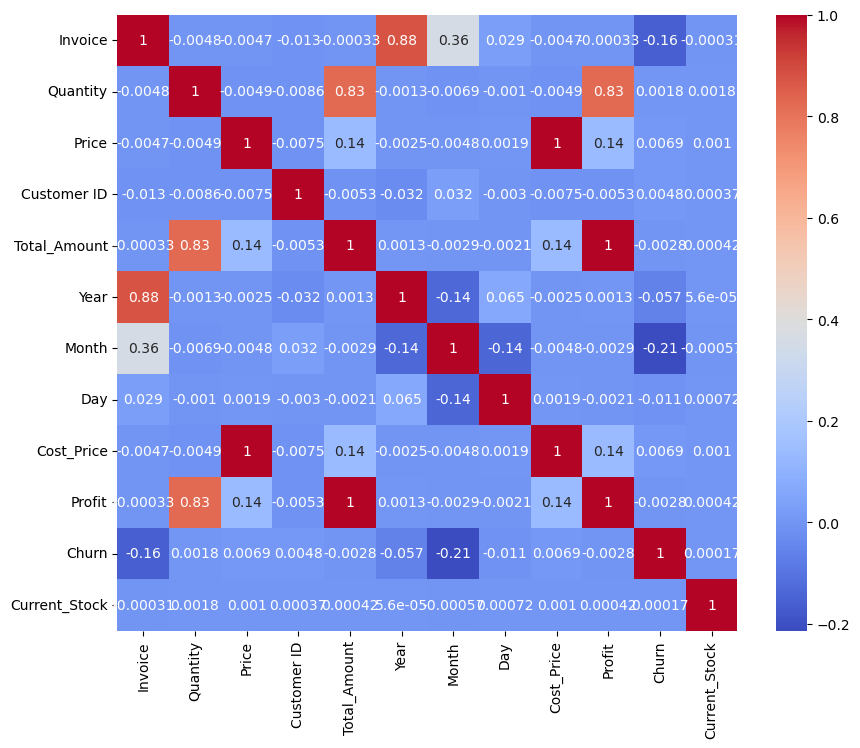

In [15]:
import seaborn as sns

plt.figure(figsize=(10,8))

sns.heatmap(
    df.select_dtypes(include='number').corr(),
    annot=True,
    cmap='coolwarm'
)

plt.show()

In [17]:
df = df.dropna()

In [19]:
df = df.drop_duplicates()

In [20]:
df['Invoice Date'] = pd.to_datetime(df['Invoice Date'])

In [23]:
df['TotalAmount'] = df['Quantity'] * df['Price']

In [25]:
snapshot_date = df['Invoice Date'].max()

In [27]:
rfm = df.groupby('Customer ID').agg({
    'Invoice Date': lambda x: (snapshot_date - x.max()).days,
    'Invoice': 'nunique',
    'TotalAmount': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

print(rfm.head())

             Recency  Frequency  Monetary
Customer ID                              
12346            325         12  77556.46
12347              1          8   5633.32
12348             74          5   2019.40
12349             18          4   4428.69
12350            309          1    334.40


In [29]:
daily_sales = df.groupby(
    df['Invoice Date'].dt.date
)['TotalAmount'].sum()

rolling_mean = daily_sales.rolling(7).mean()

print(rolling_mean.head())

Invoice Date
2009-12-01   NaN
2009-12-02   NaN
2009-12-03   NaN
2009-12-04   NaN
2009-12-05   NaN
Name: TotalAmount, dtype: float64


In [37]:
!pip install great_expectations==0.18.21
!pip install pydantic==1.10.13

   ---------------------------------------- 0.0/5.4 MB ? eta -:--:--
   --- ------------------------------------ 0.5/5.4 MB 5.6 MB/s eta 0:00:01
   ------- -------------------------------- 1.0/5.4 MB 5.6 MB/s eta 0:00:01
   ----------- ---------------------------- 1.6/5.4 MB 3.2 MB/s eta 0:00:02
   ----------------- ---------------------- 2.4/5.4 MB 3.1 MB/s eta 0:00:01
   --------------------- ------------------ 2.9/5.4 MB 3.2 MB/s eta 0:00:01
   ------------------------- -------------- 3.4/5.4 MB 3.1 MB/s eta 0:00:01
   ----------------------------- ---------- 3.9/5.4 MB 3.0 MB/s eta 0:00:01
   --------------------------------- ------ 4.5/5.4 MB 2.8 MB/s eta 0:00:01
   ------------------------------------- -- 5.0/5.4 MB 2.8 MB/s eta 0:00:01
   ---------------------------------------- 5.4/5.4 MB 2.8 MB/s eta 0:00:00
   ---------------------------------------- 0.0/813.6 kB ? eta -:--:--
   -------------------------------------- - 786.4/813.6 kB 4.8 MB/s eta 0:00:01
   -----------------


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Attempting uninstall: pydantic
    Found existing installation: pydantic 2.5.3
    Uninstalling pydantic-2.5.3:
      Successfully uninstalled pydantic-2.5.3


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.
thinc 8.3.6 requires pydantic<3.0.0,>=2.0.0, but you have pydantic 1.10.13 which is incompatible.

[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [41]:
!pip uninstall great_expectations -y
!pip uninstall pydantic -y

Found existing installation: great-expectations 0.18.21
Uninstalling great-expectations-0.18.21:
  Successfully uninstalled great-expectations-0.18.21
Found existing installation: pydantic 1.10.13
Uninstalling pydantic-1.10.13:
  Successfully uninstalled pydantic-1.10.13


In [43]:
!pip cache purge

Files removed: 1317 (2287.1 MB)


In [45]:
!pip install great_expectations==0.18.21
!pip install pydantic==1.10.13

   ---------------------------------------- 0.0/5.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/5.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/5.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/5.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/5.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/5.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/5.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/5.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/5.4 MB ? eta -:--:--
   - -------------------------------------- 0.3/5.4 MB ? eta -:--:--
   - -------------------------------------- 0.3/5.4 MB ? eta -:--:--
   - -------------------------------------- 0.3/5.4 MB ? eta -:--:--
   - -------------------------------------- 0.3/5.4 MB ? eta -:--:--
   - -------------------------------------- 0.3/5.4 MB ? eta -:--:--
   - -----------------------------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.

[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Attempting uninstall: pydantic
    Found existing installation: pydantic 2.13.4
    Uninstalling pydantic-2.13.4:
      Successfully uninstalled pydantic-2.13.4


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.
thinc 8.3.6 requires pydantic<3.0.0,>=2.0.0, but you have pydantic 1.10.13 which is incompatible.

[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [31]:
import great_expectations as gx

context = gx.get_context()

print("Validation Ready")

TypeError: ForwardRef._evaluate() missing 1 required keyword-only argument: 'recursive_guard'

In [33]:
!pip install scikit-learn


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [35]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_data = scaler.fit_transform(
    rfm[['Recency', 'Frequency', 'Monetary']]
)

In [37]:
from scipy.cluster.vq import kmeans2

centroids, labels = kmeans2(
    scaled_data,
    4,
    minit='points'
)

rfm['Cluster'] = labels

print(rfm.head())

             Recency  Frequency  Monetary  Cluster
Customer ID                                       
12346            325         12  77556.46        1
12347              1          8   5633.32        0
12348             74          5   2019.40        0
12349             18          4   4428.69        0
12350            309          1    334.40        3


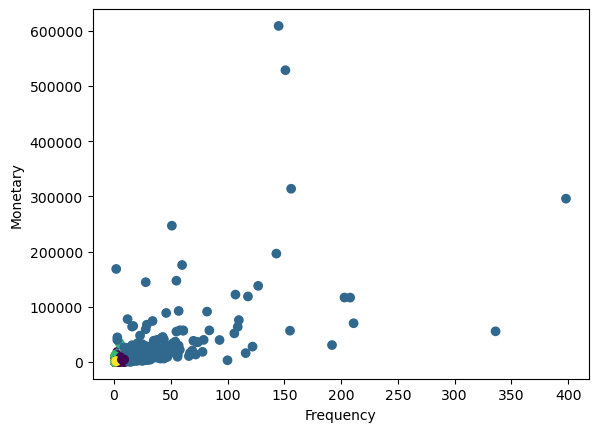

In [39]:
import matplotlib.pyplot as plt

plt.scatter(
    rfm['Frequency'],
    rfm['Monetary'],
    c=rfm['Cluster']
)

plt.xlabel("Frequency")

plt.ylabel("Monetary")

plt.show()

In [43]:
daily_sales = df.groupby(
    df['Invoice Date'].dt.date
)['TotalAmount'].sum()

daily_sales.index = pd.to_datetime(
    daily_sales.index
)

In [45]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(daily_sales)

print("ADF Statistic:", result[0])

print("P-value:", result[1])

ADF Statistic: -2.3547609747662412
P-value: 0.15491381898920892


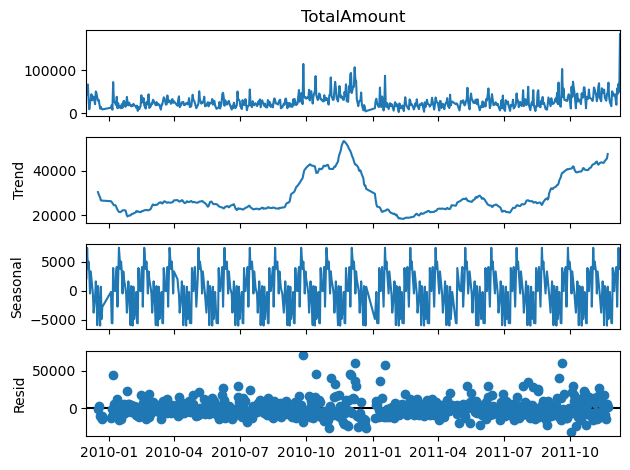

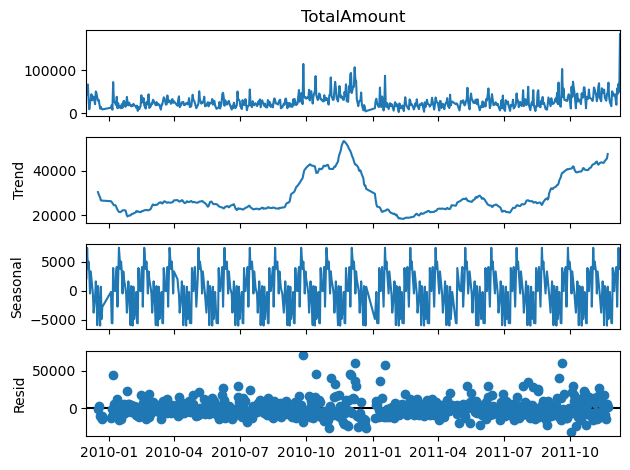

In [47]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(
    daily_sales,
    model='additive',
    period=30
)

decomposition.plot()

In [49]:
!pip install prophet


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


18:06:24 - cmdstanpy - INFO - Chain [1] start processing
18:06:25 - cmdstanpy - INFO - Chain [1] done processing


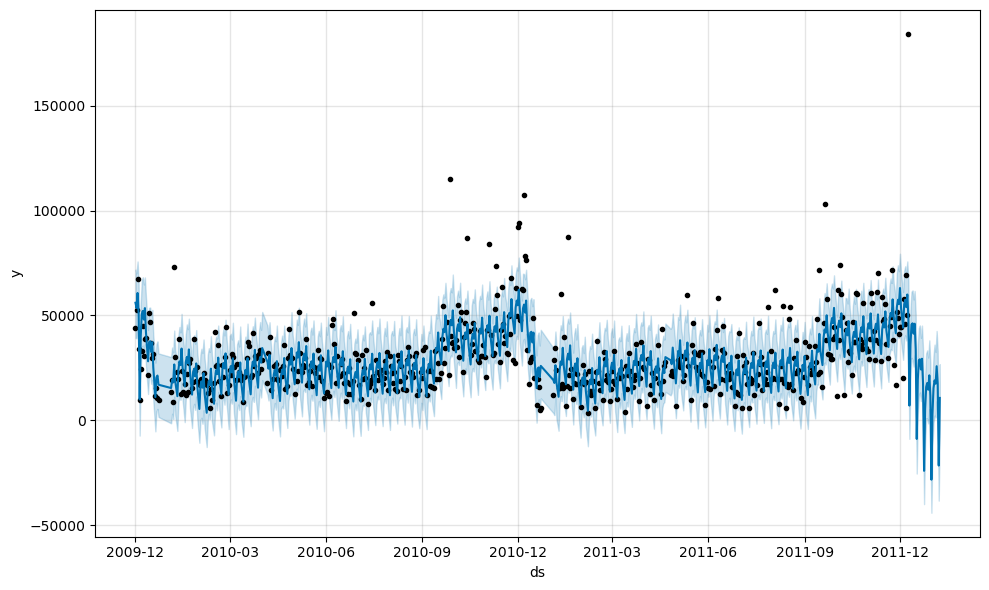

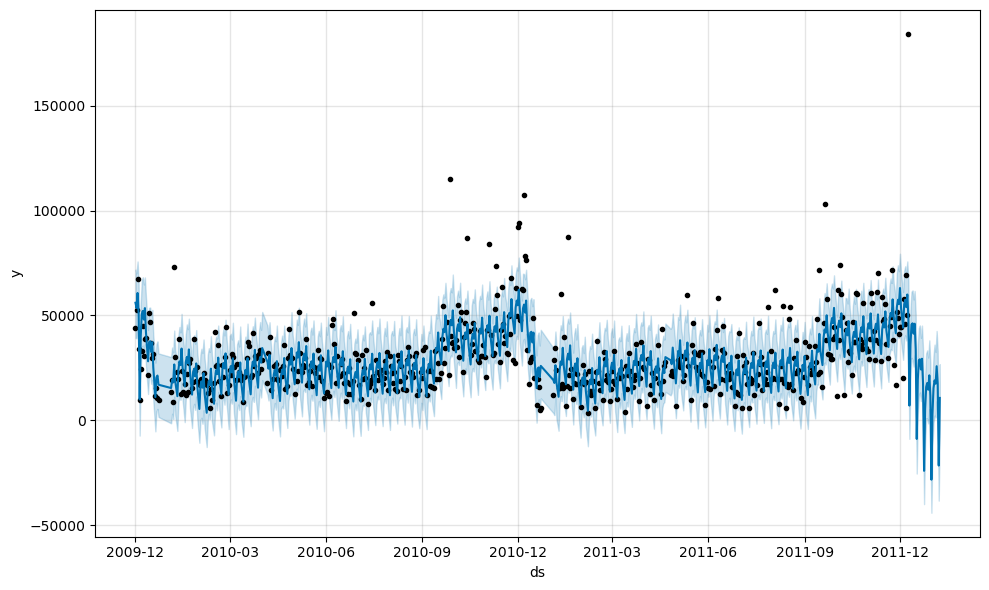

In [51]:
from prophet import Prophet

prophet_df = daily_sales.reset_index()

prophet_df.columns = ['ds', 'y']

model = Prophet()

model.fit(prophet_df)

future = model.make_future_dataframe(
    periods=30
)

forecast = model.predict(future)

model.plot(forecast)

In [53]:
!pip install torch pytorch-lightning

   ---------------------------------------- 0.0/857.3 kB ? eta -:--:--
   ---------------------------------------- 0.0/857.3 kB ? eta -:--:--
   ------------ --------------------------- 262.1/857.3 kB ? eta -:--:--
   ----------------------- -------------- 524.3/857.3 kB 985.5 kB/s eta 0:00:01
   ----------------------- -------------- 524.3/857.3 kB 985.5 kB/s eta 0:00:01
   -------------------------------------- 857.3/857.3 kB 907.2 kB/s eta 0:00:00
   ---------------------------------------- 0.0/983.4 kB ? eta -:--:--
   ---------------------------------------- 0.0/983.4 kB ? eta -:--:--
   ---------- ----------------------------- 262.1/983.4 kB ? eta -:--:--
   -------------------- ----------------- 524.3/983.4 kB 699.0 kB/s eta 0:00:01
   -------------------- ----------------- 524.3/983.4 kB 699.0 kB/s eta 0:00:01
   ------------------------------ ------- 786.4/983.4 kB 745.8 kB/s eta 0:00:01
   -------------------------------------- 983.4/983.4 kB 733.0 kB/s eta 0:00:00



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [55]:
import torch
import torch.nn as nn

class LSTMModel(nn.Module):

    def __init__(self):

        super().__init__()

        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=64,
            batch_first=True
        )

        self.fc = nn.Linear(64, 1)

    def forward(self, x):

        out, _ = self.lstm(x)

        return self.fc(out[:, -1, :])

model = LSTMModel()

print(model)

LSTMModel(
  (lstm): LSTM(1, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


In [57]:
df.to_csv(
    "cleaned_dataset.csv",
    index=False
)

In [59]:
rfm.to_csv(
    "customer_segmentation.csv"
)